## Dataset sintético para regresión (`make_regression`)

Antes de trabajar con datos reales, es útil comenzar con un **dataset sintético**, ya que nos permite enfocarnos únicamente en el **concepto de regresión**.

En un problema de regresión:
- La **variable de salida** es numérica y continua.
- El modelo aprende una relación matemática entre las variables de entrada y la salida.

`make_regression` genera datos artificiales que siguen una relación aproximadamente lineal entre:
- **X**: variable de entrada.
- **y**: variable objetivo continua.

Este tipo de dataset es ideal para:
- Visualizar claramente la relación entre X e y.
- Entender qué significa “aprender una función”.
- Evitar distracciones como datos faltantes o variables complejas.


In [1]:
from sklearn.datasets import make_regression

# Generamos un dataset de regresión con una sola variable
X, y = make_regression(
    n_samples=120,
    n_features=1,
    noise=5,
    random_state=42
)


## Exploración visual de los datos

Antes de entrenar un modelo, es importante **visualizar los datos**.  
Esto nos permite entender:
- Si existe una relación entre la variable de entrada (**X**) y la variable objetivo (**y**).
- Si la relación parece aproximadamente lineal.
- Qué tan dispersos están los datos (ruido).

En un problema de regresión simple con una sola variable, una gráfica de dispersión
(*scatter plot*) es suficiente para observar el comportamiento general de los datos.


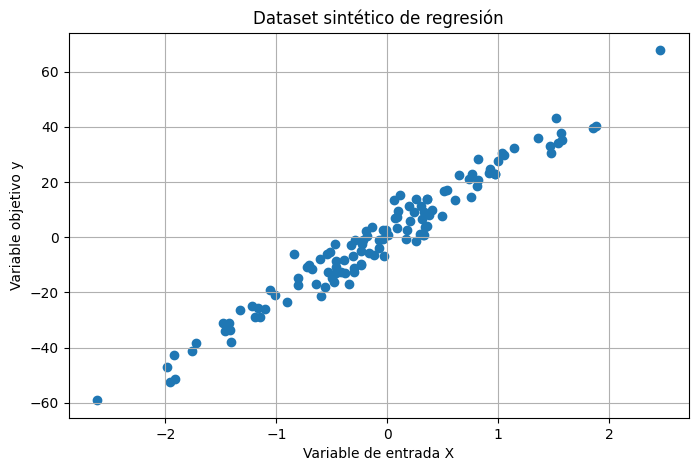

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.title("Dataset sintético de regresión")
plt.xlabel("Variable de entrada X")
plt.ylabel("Variable objetivo y")
plt.grid(True)
plt.show()


## Entrenamiento de un modelo de regresión lineal

Una vez que entendemos visualmente los datos, el siguiente paso es **entrenar un modelo**.

En este caso utilizaremos **Regresión Lineal**, uno de los algoritmos más simples y
fundamentales del aprendizaje supervisado para problemas de regresión.

La idea central es que el modelo aprende una función de la forma:

y = mX + b

donde:
- **m** es la pendiente (cuánto cambia y cuando cambia X).
- **b** es el sesgo o intercepto (valor de y cuando X = 0).

El objetivo del entrenamiento es encontrar los valores de *m* y *b* que mejor se ajusten
a los datos observados.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# Creamos y entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Predicción sobre datos no observados

Una vez entrenado el modelo, podemos usarlo para **realizar predicciones**.
Esto significa aplicar la función aprendida a datos que el modelo **no vio durante el entrenamiento**.

Este paso es clave en el aprendizaje supervisado, ya que el verdadero objetivo del modelo
no es memorizar los datos de entrenamiento, sino **generalizar** y producir buenas
predicciones en nuevos datos.


In [4]:
# Realizamos predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)


## Comparación entre valores reales y valores predichos

Para entender qué ha aprendido el modelo, es muy útil **comparar visualmente**
los valores reales con los valores predichos.

En una regresión simple:
- Los **puntos** representan los valores reales del dataset.
- La **línea** representa la función aprendida por el modelo.

Si el modelo ha aprendido correctamente la relación entre X e y,
la línea debería aproximarse bien a la tendencia general de los datos.


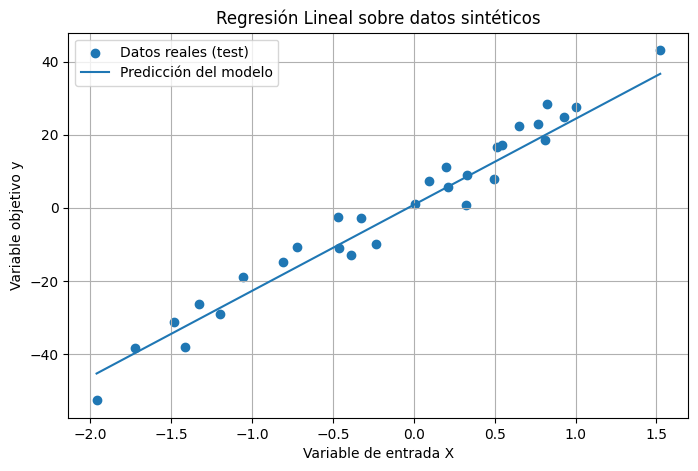

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Ordenamos los datos para que la línea se vea correctamente
order = np.argsort(X_test[:, 0])
X_test_sorted = X_test[order]
y_pred_sorted = y_pred[order]

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label="Datos reales (test)")
plt.plot(X_test_sorted, y_pred_sorted, label="Predicción del modelo")
plt.title("Regresión Lineal sobre datos sintéticos")
plt.xlabel("Variable de entrada X")
plt.ylabel("Variable objetivo y")
plt.legend()
plt.grid(True)
plt.show()


## Interpretación del modelo aprendido

Además de ver la línea en la gráfica, podemos inspeccionar los parámetros que aprendió
la regresión lineal para entender su comportamiento.

La ecuación general del modelo es:

y = mX + b

donde:
- **m (pendiente)** indica cuánto cambia la predicción de **y** cuando **X** aumenta en una unidad.
- **b (intercepto)** es el valor base de **y** cuando **X = 0**.

Mostrar estos valores ayuda a reforzar la idea de que el modelo aprendió una función
matemática a partir de ejemplos.


In [6]:
m = model.coef_[0]
b = model.intercept_

print(f"Pendiente (m): {m}")
print(f"Intercepto (b): {b}")
print(f"Ecuación del modelo: y = ({m:.2f}) * X + ({b:.2f})")


Pendiente (m): 23.55610044444119
Intercepto (b): 0.8175987519441346
Ecuación del modelo: y = (23.56) * X + (0.82)
